# 🧠 Clasificador de setas con redes neuronales usando Transfer Learning

## 📦 1. Carga de librerías necesarias

In [1]:
import os
import pathlib
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.applications import ResNet50V2
import tensorflow_hub as hub
import numpy as np
from matplotlib import pyplot as plt


Estas librerías permiten:
- `tensorflow`, `keras`: crear, entrenar y evaluar redes neuronales.
- `tensorflow_hub`: cargar modelos preentrenados.
- `matplotlib`: visualizar resultados.


## 📁 2. Descarga y descompresión del dataset

In [4]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c utkml-predict-mushroom-species -p /content/ --force
!unzip -q /content/utkml-predict-mushroom-species.zip -d /content/dataset/

 96% 909M/949M [00:04<00:00, 110MB/s] 
100% 949M/949M [00:04<00:00, 216MB/s]


## Creación del dataset de validación

In [5]:
import random
import shutil

# Parámetros
SEED = 42
SRC_ROOT = pathlib.Path('/content/dataset/mushrooms_train/mushrooms_train')
DST_ROOT = pathlib.Path('/content/dataset/mushrooms_train/mushrooms_val')
VAL_RATIO = 0.2

random.seed(SEED)

# 1) Asegurarse de que existe la carpeta destino
DST_ROOT.mkdir(parents=True, exist_ok=True)

# 2) Para cada clase
for class_dir in SRC_ROOT.iterdir():
    if not class_dir.is_dir():
        continue

    # Ruta de destino para esta clase
    dst_class_dir = DST_ROOT / class_dir.name
    dst_class_dir.mkdir(parents=True, exist_ok=True)

    # Listado de imágenes en origen
    images = list(class_dir.glob('*'))
    n_val = int(len(images) * VAL_RATIO)

    # Selección aleatoria
    val_images = set(random.sample(images, n_val))

    # 3) Mover ficheros seleccionados
    for img_path in val_images:
        target_path = dst_class_dir / img_path.name
        shutil.move(str(img_path), str(target_path))

    print(f'Clase {class_dir.name}: movidas {len(val_images)} / {len(images)} imágenes a validación.')

print('Proceso completado.')

Clase Lactarius: movidas 281 / 1406 imágenes a validación.
Clase Boletus: movidas 192 / 963 imágenes a validación.
Clase Amanita: movidas 135 / 675 imágenes a validación.
Clase Hygrocybe: movidas 57 / 286 imágenes a validación.
Clase Russula: movidas 206 / 1031 imágenes a validación.
Clase Cortinarius: movidas 150 / 752 imágenes a validación.
Clase Entoloma: movidas 65 / 328 imágenes a validación.
Clase Suillus: movidas 56 / 280 imágenes a validación.
Clase Agaricus: movidas 63 / 318 imágenes a validación.
Proceso completado.


## 🧹 3. Preparación del dataset

In [6]:
data_dir = pathlib.Path('/content/dataset/mushrooms_train/mushrooms_train')
class_names = sorted(os.listdir(data_dir))
print(f"Clases encontradas: {class_names}")
print(f"Número de clases: {len(class_names)}")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/mushrooms_train/mushrooms_train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_mode='categorical',
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/mushrooms_train/mushrooms_val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,      # ya no hay sesgo de carpetas
    label_mode='categorical',
    seed=SEED
)

class_names = train_ds.class_names
print(f"Clases encontradas en el train: {class_names}")
print(f"Número de clases en el train: {len(class_names)}")

Clases encontradas: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
Número de clases: 9
Found 4834 files belonging to 9 classes.
Found 1205 files belonging to 9 classes.
Clases encontradas en el train: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
Número de clases en el train: 9



Usamos `image_dataset_from_directory` para crear datasets de entrenamiento y validación a partir de carpetas con imágenes organizadas por clase.

Se hace un **split 80/20** con `validation_split` y se reescalan las imágenes a `224x224`, que es el tamaño requerido por **ResNetV2-50**.


## 🔄 4. Aumento y normalización de datos

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
], name="data_augmentation")

"""
def prepare_dataset(ds, augment=False):
    rescale = layers.Rescaling(1./255)
    ds = ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds_prepared = prepare_dataset(train_ds, augment=True)
val_ds_prepared = prepare_dataset(val_ds)
"""

train_ds_prepared = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds_prepared = train_ds_prepared.cache().prefetch(buffer_size=AUTOTUNE)

# Solo necesitamos optimizar el pipeline de validación, sin aumento de datos.
val_ds_prepared = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
# --- Verificación (Opcional pero recomendado) ---
# Ahora, este código SÍ debería funcionar y mostrar todas las clases.
import numpy as np

y_true_check = np.concatenate([y for x, y in val_ds_prepared], axis=0)
y_true_indices = np.argmax(y_true_check, axis=1)

valores_unicos, conteos = np.unique(y_true_indices, return_counts=True)

print("\nConteo de etiquetas en el conjunto de validación (CORREGIDO):")
for valor, conteo in zip(valores_unicos, conteos):
    clase_nombre = class_names[valor]
    print(f"  - {clase_nombre}: {conteo} imágenes")
print(y_true_check)


Conteo de etiquetas en el conjunto de validación (CORREGIDO):
  - Agaricus: 63 imágenes
  - Amanita: 135 imágenes
  - Boletus: 192 imágenes
  - Cortinarius: 150 imágenes
  - Entoloma: 65 imágenes
  - Hygrocybe: 57 imágenes
  - Lactarius: 281 imágenes
  - Russula: 206 imágenes
  - Suillus: 56 imágenes
[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]



**Aumento de datos (Data Augmentation)**:
- Se aplican transformaciones aleatorias como rotación, zoom y volteo horizontal solo al set de entrenamiento.
- Esto ayuda a evitar el **sobreajuste**, haciendo que el modelo vea variaciones de las mismas imágenes.

**Normalización**: los valores de los píxeles se reescalan a [0, 1].

**`cache()` y `prefetch()`**: mejoran el rendimiento al evitar cuellos de botella durante el entrenamiento.


## 🏗️ 5. Construcción del modelo con Transfer Learning

In [9]:
class_names

['Agaricus',
 'Amanita',
 'Boletus',
 'Cortinarius',
 'Entoloma',
 'Hygrocybe',
 'Lactarius',
 'Russula',
 'Suillus']

In [10]:
PRETRAINED_MODEL_PATH = 'https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5'
IMG_SIZE = (224, 224)
num_classes = len(class_names)

base_model = ResNet50V2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# 2. Congelar la capa base para no re-entrenarla
base_model.trainable = False

# 3. Construir el modelo final apilando capas con la API Sequential
model = tf.keras.Sequential([
    # La capa base actúa como un extractor de características.
    base_model,
    # Nuestro cabezal de clasificación personalizado.
    layers.Dense(512, activation='relu', name='classifier_dense_1'),
    layers.Dropout(0.5, name='classifier_dropout'),
    layers.Dense(num_classes, activation='softmax', name='output_layer')
])

model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense_1 (Dense)      │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,618,505 (93.91 MB)

 Trainable params: 1,053,705 (4.02 MB)

 Non-trainable params: 23,564,800 (89.89 MB)


### ✨ Justificación de la arquitectura

#### 🔹 Capa Base: `hub.KerasLayer`
- Modelo: **ResNetV2-50** preentrenado en ImageNet (1000 clases).
- `trainable=False`: **congelamos** sus pesos. Lo usamos como **extractor de características**.
- Esto se llama **Aprendizaje por Transferencia**.

#### 🔹 Cabezal de Clasificación:
1. `Dense(512, activation='relu')`: capa densa que empieza a aprender combinaciones útiles para distinguir entre clases.
2. `Dropout(0.5)`: apaga aleatoriamente el 50% de las neuronas para **evitar sobreajuste**.
3. `Dense(num_classes, activation='softmax')`: capa final de salida. Cada neurona representa una clase de seta.

> ✅ Usamos la capacidad de ResNet para "ver", y entrenamos solo un pequeño clasificador encima para adaptarlo al problema específico.


## ⚙️ 6. Compilación y entrenamiento del modelo

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_mushroom_classifier.keras',
        save_best_only=True,
        monitor='val_loss')
]

EPOCHS = 10


Se compila el modelo con:
- `loss='categorical_crossentropy'`: clasificación multiclase.
- `optimizer=Adam`: buen rendimiento con tasa baja de aprendizaje (0.0001).

Se entrena durante **10 épocas** y se guarda el mejor modelo usando `ModelCheckpoint`.


In [22]:
history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
    callbacks=callbacks,
)

print("Entrenamiento finalizado.")

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.2315 - loss: 2.2727 - val_accuracy: 0.2108 - val_loss: 2.2680
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 29s 87ms/step - accuracy: 0.2272 - loss: 2.2545 - val_accuracy: 0.2116 - val_loss: 2.2482
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.2344 - loss: 2.2336 - val_accuracy: 0.1876 - val_loss: 2.3602
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.2307 - loss: 2.2411 - val_accuracy: 0.1817 - val_loss: 2.3323
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.2253 - loss: 2.2326 - val_accuracy: 0.2274 - val_loss: 2.2049
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.2286 - loss: 2.2473 - val_accuracy: 0.2124 - val_loss: 2.2229
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2267 - loss: 2.2431 - val_accuracy: 0.2241 - val_loss: 2.2193
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.2287 - loss: 2.2260 -

## Mejoras

Podemos hacer que el peso de cada clase sea inversamente proporcional al número de fotos que tenemos en el dataset.

In [21]:
from sklearn.utils import class_weight
import numpy as np

# 1) Extraer etiquetas de train_ds_prepared
y_train = np.concatenate([y for x, y in train_ds_prepared], axis=0)
y_train_idx = np.argmax(y_train, axis=1)

# 2) Calcular class_weight
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=y_train_idx
)
class_weight_dict = dict(enumerate(weights))

print("Pesos por clase:", class_weight_dict)

Pesos por clase: {0: np.float64(2.106318082788671), 1: np.float64(0.9946502057613169), 2: np.float64(0.6966421674592881), 3: np.float64(0.8922111480251015), 4: np.float64(2.042247570764681), 5: np.float64(2.3454633672974285), 6: np.float64(0.4774320987654321), 7: np.float64(0.6510437710437711), 8: np.float64(2.3978174603174605)}


## Opcional, descongelar capas o modificar el learning rate



In [30]:

# Descongelar, por ejemplo, las últimas 20 capas
for layer in base_model.layers[-20:]:
    layer.trainable = True

EPOCHS_FINETUNE = 12

# 2) Recompilar con learning rate más bajo
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



Epoch 1/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 42s 181ms/step - accuracy: 0.2249 - loss: 2.1165 - val_accuracy: 0.2614 - val_loss: 2.0607
Epoch 2/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.2385 - loss: 2.0542 - val_accuracy: 0.2614 - val_loss: 2.0145
Epoch 3/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.2399 - loss: 2.0263 - val_accuracy: 0.2697 - val_loss: 1.9870
Epoch 4/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.2481 - loss: 2.0061 - val_accuracy: 0.2871 - val_loss: 1.9663
Epoch 5/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.2556 - loss: 1.9906 - val_accuracy: 0.2979 - val_loss: 1.9496
Epoch 6/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.2646 - loss: 1.9615 - val_accuracy: 0.3178 - val_loss: 1.9344
Epoch 7/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.2875 - loss: 1.9372 - val_accuracy: 0.3220 - val_loss: 1.9191
Epoch 8/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.2870 - loss: 1

In [37]:
# Entrenar de nuevo (con callbacks de early stopping)
history_finetune = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    class_weight=class_weight_dict,
    epochs=EPOCHS_FINETUNE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        *callbacks
    ]
)


Epoch 1/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.5505 - loss: 1.3684 - val_accuracy: 0.4166 - val_loss: 1.6929
Epoch 2/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.5497 - loss: 1.3432 - val_accuracy: 0.4174 - val_loss: 1.6910
Epoch 3/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.5706 - loss: 1.3142 - val_accuracy: 0.4075 - val_loss: 1.6919
Epoch 4/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.5810 - loss: 1.2839 - val_accuracy: 0.4058 - val_loss: 1.6923
Epoch 5/12
152/152 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.5948 - loss: 1.2482 - val_accuracy: 0.4025 - val_loss: 1.6997


### Cargar el Modelo Guardado

Para cargar el modelo que guardaste (best_mushroom_classifier.keras), simplemente usamos la función tf.keras.models.load_model. Este modelo ya estará compilado y con los mejores pesos que se guardaron durante el entrenamiento.

In [38]:
import tensorflow as tf

# Cargar el mejor modelo que se guardó durante el entrenamiento
print("Cargando el modelo guardado desde 'best_mushroom_classifier.keras'...")
loaded_model = tf.keras.models.load_model('/content/best_mushroom_classifier 4183.keras')

# (Opcional) Mostrar el resumen para verificar que se cargó correctamente
loaded_model.summary()

Cargando el modelo guardado desde 'best_mushroom_classifier.keras'...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense_1 (Dense)      │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,485,277 (162.07 MB)

 Trainable params: 8,933,385 (34.08 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

 Optimizer params: 17,866,772 (68.16 MB)

### Elegir, Mostrar y Predecir una Imagen Individual

Este bloque de código hace exactamente lo que pides:

1. Elige una clase de seta al azar.
2. Elige una imagen al azar de esa clase.
3. Muestra la imagen en pantalla.
4. La preprocesa para que tenga el formato correcto que espera el modelo.
5. Realiza la predicción.
6. Muestra el resultado de forma clara.

Clase real de la imagen seleccionada: Lactarius
Ruta de la imagen: /content/dataset/mushrooms_train/mushrooms_train/Lactarius/0825_nsPts-tdiSE.jpg


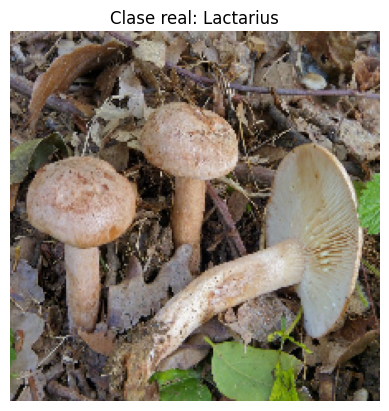

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Predicción del modelo: Lactarius
Confianza de la predicción: 37.25%

¡La predicción es CORRECTA! ✅

Top 3 predicciones:
  - Lactarius: 37.25%
  - Russula: 13.99%
  - Cortinarius: 11.89%


In [43]:
import random
import os
from tensorflow.keras.preprocessing import image
import numpy as np
from matplotlib import pyplot as plt

# --- Paso 1: Seleccionar una imagen al azar ---

# Elegir una clase (una carpeta) al azar
random_class = random.choice(class_names)
class_path = os.path.join(data_dir, random_class)

# Elegir una imagen al azar de esa clase
random_image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image_name)

print(f"Clase real de la imagen seleccionada: {random_class}")
print(f"Ruta de la imagen: {image_path}")

# --- Paso 2: Cargar y mostrar la imagen ---

# Cargar la imagen para mostrarla (sin preprocesar)
# Usamos el módulo 'image' de Keras que es muy conveniente
display_img = image.load_img(image_path, target_size=IMG_SIZE)

plt.imshow(display_img)
plt.title(f"Clase real: {random_class}")
plt.axis('off')
plt.show()

# --- Paso 3: Preprocesar la imagen para la predicción ---

# 1. Convertir la imagen a un array de NumPy
img_array = image.img_to_array(display_img)

# 2. Añadir una dimensión para crear un "lote" de una sola imagen
#    El modelo espera una entrada con forma (lote, alto, ancho, canales),
#    por lo que pasamos de (224, 224, 3) a (1, 224, 224, 3).
img_batch = np.expand_dims(img_array, axis=0)

# 3. La normalización (reescalado 0-1) ya está incluida en el modelo ResNetV2,
#    por lo que no es necesario preprocesarla manualmente aquí. ¡Muy eficiente!

# --- Paso 4: Realizar y mostrar la predicción ---

# Usar el modelo cargado para predecir
predictions = loaded_model.predict(img_batch)

# `predictions` es un array con las probabilidades para cada clase (gracias a softmax)
# Por ejemplo: [[0.01, 0.05, 0.92, 0.02, ...]]

# Obtener el índice de la clase con la probabilidad más alta
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
prediction_confidence = np.max(predictions[0]) * 100

# Mostrar el resultado de forma clara
print(f"\nPredicción del modelo: {predicted_class_name}")
print(f"Confianza de la predicción: {prediction_confidence:.2f}%")

# Comprobar si la predicción es correcta
if predicted_class_name == random_class:
    print("\n¡La predicción es CORRECTA! ✅")
else:
    print(f"\nLa predicción es INCORRECTA. ❌ (Clase real: {random_class})")

# Opcional: Mostrar las 3 predicciones principales
top_3_indices = np.argsort(predictions[0])[-3:][::-1]
print("\nTop 3 predicciones:")
for i in top_3_indices:
    print(f"  - {class_names[i]}: {predictions[0][i]*100:.2f}%")

### Cómo funciona este último bloque:

- **Selección aleatoria**: Se usan las librerías os y random para navegar por los directorios de tu dataset y elegir una imagen al azar. Esto hace que las pruebas sean imparciales.
- **Carga de imagen**: image.load_img es una función muy útil de Keras para cargar una imagen desde una ruta y redimensionarla al target_size que el modelo necesita.
- **Preprocesamiento para el modelo**:
    - image.img_to_array convierte la imagen en un formato numérico (NumPy array) que TensorFlow puede entender.
    - np.expand_dims es crucial. Los modelos de Keras siempre esperan un "lote" (o *batch*) de imágenes, incluso si solo le pasas una. Esta función añade una dimensión extra al principio del array, convirtiendo una imagen individual en un lote de tamaño 1.
- **Predicción**:
    - loaded_model.predict() devuelve un array de probabilidades, una para cada clase.
    - np.argmax() encuentra el índice del valor más alto en ese array. Este índice corresponde a la posición de la clase predicha en tu lista class_names.
    - np.max() obtiene el valor de probabilidad más alto, que es la "confianza" del modelo en su predicción.

Realizando predicciones en el conjunto de validación...
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step
Etiquetas reales y predicciones obtenidas.


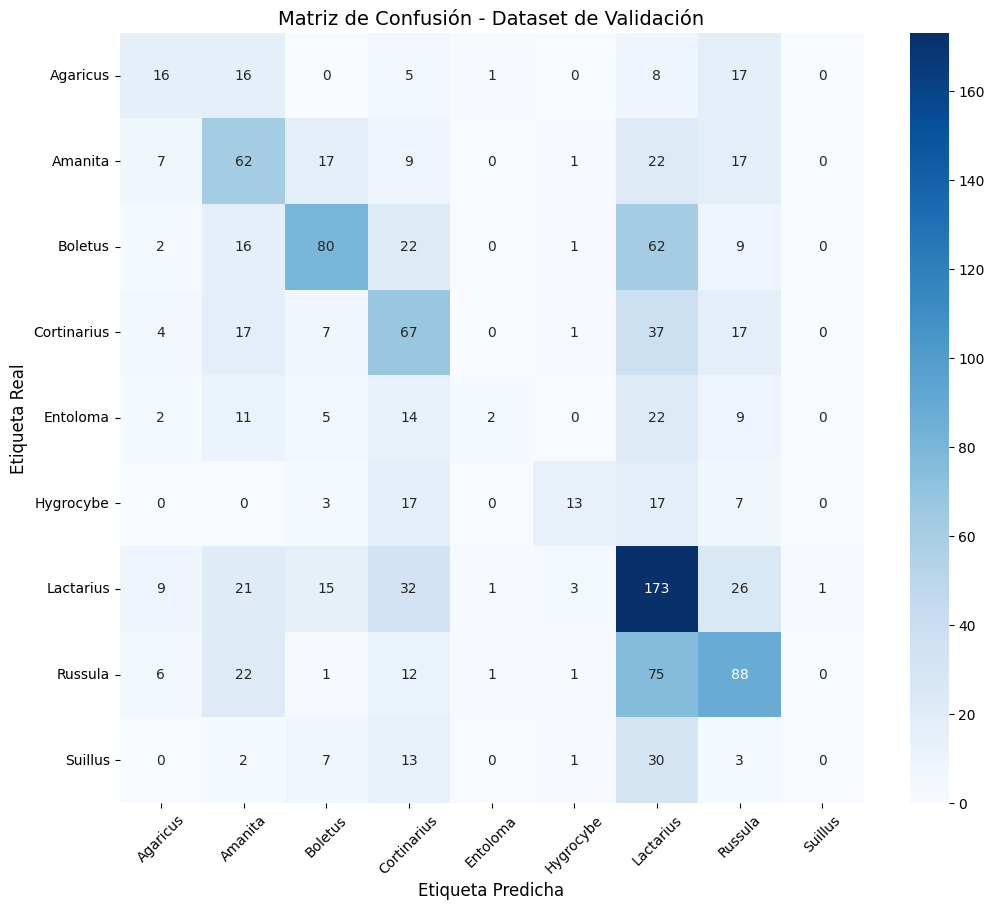


             Reporte de Clasificación (Validación)

              precision    recall  f1-score   support

    Agaricus       0.35      0.25      0.29        63
     Amanita       0.37      0.46      0.41       135
     Boletus       0.59      0.42      0.49       192
 Cortinarius       0.35      0.45      0.39       150
    Entoloma       0.40      0.03      0.06        65
   Hygrocybe       0.62      0.23      0.33        57
   Lactarius       0.39      0.62      0.48       281
     Russula       0.46      0.43      0.44       206
     Suillus       0.00      0.00      0.00        56

    accuracy                           0.42      1205
   macro avg       0.39      0.32      0.32      1205
weighted avg       0.42      0.42      0.39      1205



In [44]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt

# --- Paso 1: Usar el Dataset de Validación ya preparado ---
# La variable 'val_ds_prepared' ya contiene el dataset de validación
# optimizado con .cache() y .prefetch().

# --- Paso 2: Obtener las etiquetas reales y las predicciones del conjunto de validación ---

# Usaremos el modelo ya cargado o recién entrenado ('loaded_model' o 'model')
print("Realizando predicciones en el conjunto de validación...")
y_pred_probs = loaded_model.predict(val_ds_prepared)

# Convertir las probabilidades en la clase predicha (el índice con el valor más alto)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extraer las etiquetas reales del dataset de validación
# .unbatch() deshace los lotes para que podamos iterar sobre cada ejemplo individualmente.
y_true = np.concatenate([y for x, y in val_ds_prepared], axis=0)
# Convertir las etiquetas one-hot a índices de clase
y_true = np.argmax(y_true, axis=1)

print("Etiquetas reales y predicciones obtenidas.")

# --- Paso 3: Generar y visualizar la Matriz de Confusión ---

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)

# Crear la visualización con Seaborn para que sea más bonita y clara
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix,
            annot=True,     # Muestra los números en cada celda
            fmt='g',        # Formato de los números (entero, sin notación científica)
            cmap='Blues',   # Paleta de colores
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.title('Matriz de Confusión - Dataset de Validación', fontsize=14)
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para que no se solapen
plt.yticks(rotation=0)  # Mantener las etiquetas del eje y horizontales
plt.show()

# --- (Opcional pero recomendado) Paso 4: Mostrar el Reporte de Clasificación ---

print("\n" + "="*50)
print("             Reporte de Clasificación (Validación)")
print("="*50 + "\n")
print(classification_report(y_true, y_pred, target_names=class_names))